In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os, fnmatch
from astropy.cosmology import FlatLambdaCDM
import astropy.units as u

cosmo = FlatLambdaCDM(H0=70 * u.km / u.s / u.Mpc, Tcmb0=2.725 * u.K, Om0=0.3)
c=3*10**5

%matplotlib inline

In [2]:
# Log path
lenstool_log_path = "/home/joao/Documents/Research/4_sys_analysis/LOG/"
pyautolens_log_path ="/home/joao/Documents/Research/4_sys_analysis/output/"

In [3]:
def get_percentiles_lenstool(name, percentiles=[16, 50, 84]):
    """
    name: path of the system
    percentiles: percentiles for the statistics (remember: 50=average value)
    """
    dataframe=pd.read_csv(lenstool_log_path+name+"/bayes.dat",
            comment='#',
            usecols = [1,2,3,4,5,6,7],
            names=["log", "x", "y", "e", "theta", "sigma", "chi2"],
            sep=" ",
            index_col=False)
    #return np.percentile(dataframe["x"], [16, 50, 84]), np.percentile(dataframe["y"], [16, 50, 84]), np.percentile(dataframe["e"], [16, 50, 84]), np.percentile(dataframe["theta"], [16, 50, 84]), np.percentile(dataframe["sigma"], [16, 50, 84])
    return np.percentile(dataframe["x"], [16, 50, 84]), np.percentile(dataframe["y"], [16, 50, 84]), np.percentile(dataframe["e"], [16, 50, 84]), np.percentile(dataframe["theta"], [16, 50, 84]), np.percentile(dataframe["sigma"], [16, 50, 84])


In [4]:
def find(pattern, path):
    result = []
    for root, dirs, files in os.walk(path):
        for name in files:
            if fnmatch.fnmatch(name, pattern):
                result.append(os.path.join(root, name))
    return result

In [5]:
def convert_thetae_sigmav(z_l, z_s, theta_e, theta_e_err1, theta_e_err2):
    #arcsec to radians
    arcsec_to_rad_factor = 4.84814*10**(-6)
    theta_e=theta_e*arcsec_to_rad_factor
    
    d_l=cosmo.angular_diameter_distance(z_l).value
    d_s=cosmo.angular_diameter_distance(z_s).value
    factor=1-(d_l/d_s)*(1+z_l)/(1+z_s)
    sigma_v = np.sqrt((c**2/(4*np.pi))*theta_e*1/factor)
    
    sigma_v_err1 = np.sqrt((c**2/(4*np.pi))*1/factor)*theta_e_err1/(2*np.sqrt(theta_e))*arcsec_to_rad_factor
    sigma_v_err2 = np.sqrt((c**2/(4*np.pi))*1/factor)*theta_e_err2/(2*np.sqrt(theta_e))*arcsec_to_rad_factor
    
    return sigma_v-sigma_v_err1, sigma_v, sigma_v+sigma_v_err2

In [6]:
def convert_ellcomp_exc_ang(ell_comp_x, ell_comp_y):
    
    q=(1-np.sqrt(ell_comp_x**2+ell_comp_y**2))/(1+np.sqrt(ell_comp_x**2+ell_comp_y**2))
    
    exc=np.sqrt(1-q**2)
    ang=0.5*np.arccos(ell_comp_x*(1+q)/(1-q))
    
    return exc, ang

In [7]:
def get_percentiles_pyautolens(name, percentiles=[16, 50, 84]):
    """
    name: path of the system
    percentiles: percentiles for the statistics (remember: 50=average value)
    """
    
    path_bayes=find('samples.csv', pyautolens_log_path+name)[0]
    model_results_path=find('model.results', pyautolens_log_path+name)[0]
    
    file=open(model_results_path)
    lines=file.readlines()
    file.close()
    
    z_lens=float(lines[64][20:])
    z_source=1.0
    print(z_lens)
    
    dataframe=pd.read_csv(path_bayes,
                          sep=",",
                          index_col=False)
    
    theta_e = np.percentile(dataframe["galaxies_lens_mass_einstein_radius"], [16, 50, 84])
    
    excentricity, angle = convert_ellcomp_exc_ang(dataframe["galaxies_lens_mass_elliptical_comps_1"], ell_comp_y=dataframe["galaxies_lens_mass_elliptical_comps_0"])
    
    return np.percentile(dataframe["galaxies_lens_mass_centre_1"], [16, 50, 84]), np.percentile(dataframe["galaxies_lens_mass_centre_0"], [16, 50, 84]), np.percentile(excentricity, [16, 50, 84]), np.percentile(angle, [16, 50, 84]), convert_thetae_sigmav(z_lens, z_source, theta_e[1], theta_e[1]-theta_e[0], theta_e[2]-theta_e[1])


In [8]:
get_percentiles_pyautolens("sys4")

0.53


(array([-0.0516018 ,  0.03981524,  0.10577231]),
 array([-0.0819631 , -0.00563726,  0.07575129]),
 array([0.69864367, 0.89109745, 0.97504691]),
 array([0.12152614, 0.80113548, 1.21614176]),
 (272.6761886093959, 310.0024868299136, 441.966589888769))

In [9]:
anna_results_path = "/home/joao/Documents/Research/4_sys_analysis/LOG/results/anna_results.txt"

In [10]:
anna_results=pd.read_csv(anna_results_path,
                         comment='#',
                         names=["x", "x_err", "y", "y_err", "e", "e_err", "theta", "theta_err", "sigma", "sigma_err", "sys"],
                         sep="\s+",
                         index_col=False)
anna_results.head()

,x,x_err,y,y_err,e,e_err,theta,theta_err,sigma,sigma_err,sys
0,0.71,0.08,0.05,0.11,0.11,0.008,9.28,1.30,440.58,1.40,1
1,0.72,0.08,0.04,0.15,0.08,0.120,4.90,24.95,434.59,2.96,1
2,0.53,0.09,-0.17,0.11,0.32,0.060,6.41,1.27,442.03,3.26,1
3,NaN,NaN,NaN,NaN,0.51,0.000,164.10,0.00,524.00,0.00,2
4,NaN,NaN,NaN,NaN,0.51,0.000,164.00,0.00,525.00,8.90,2


In [11]:
params_dict={
    1:"x",
    2:"y",
    3:"e",
    4:"theta",
    5:"sigma"
}
colorcode={
    0:"green",
    1:"k",
    2:"teal",
    3:"r",
    4:"blue",
    5:"purple"
}
legend={
    0:"Anna DS9",
    1:"Anna barycenter",
    2:"Anna Best Bright",
    3:"without counter image",
    4:"w/ counter image",
    5:"lenstool"
}
param_latex_dict = {
    1:"x",
    2:"y",
    3:"e",
    4:"θ",
    5:"σ"
}

In [12]:
def confidence_plot(sys):
    """
    sys= system number eg. 1, 2, 3, 4
    """
    anna_result_sysfixed=anna_results[anna_results["sys"]==sys]
    anna_result_sysfixed.reset_index(drop=True, inplace=True)
    percentiles=get_percentiles_lenstool("sys_"+str(sys))
    percentiles_pyautolens=get_percentiles_pyautolens("sys"+str(sys))
    
    fig = plt.figure(figsize=plt.figaspect(0.2), frameon=True)
    if sys != 2:
        percentiles_ci=get_percentiles_lenstool("sys_"+str(sys)+"_ci")
    
    for ii in range(1, 6):
        ax = fig.add_subplot(1, 6, ii)
        for jj in range(0, len(anna_result_sysfixed)):
            #print(anna_result_sysfixed[params_dict[ii]][jj])
            #print(np.array([anna_result_sysfixed[str(params_dict[ii])+"_err"][jj], anna_result_sysfixed[str(params_dict[ii])+"_err"][jj]]))
            if ii == 5:
                #print(legend[jj])
                ax.errorbar(float(anna_result_sysfixed[params_dict[ii]][jj]), jj, xerr=float(anna_result_sysfixed[str(params_dict[ii])+"_err"][jj]), fmt='o', c=str(colorcode[jj]), label=legend[jj])
            else:
                ax.errorbar(float(anna_result_sysfixed[params_dict[ii]][jj]), jj, xerr=float(anna_result_sysfixed[str(params_dict[ii])+"_err"][jj]), fmt='o', c=str(colorcode[jj]))

        if ii == 5:
            ax.errorbar(float(percentiles[ii-1][1]), jj+1, xerr=np.array([[float(percentiles[ii-1][1])-float(percentiles[ii-1][0])], [float(percentiles[ii-1][2])-float(percentiles[ii-1][1])]]), fmt='o', c=str(colorcode[jj+1]), label=legend[jj+1])
            if sys != 2:
                ax.errorbar(float(percentiles_ci[ii-1][1]), jj+2, xerr=np.array([[float(percentiles_ci[ii-1][1])-float(percentiles_ci[ii-1][0])], [float(percentiles_ci[ii-1][2])-float(percentiles_ci[ii-1][1])]]), fmt='o', c=str(colorcode[jj+2]), label=legend[jj+2])
            ax.errorbar(float(percentiles_pyautolens[ii-1][1]), jj+3, xerr=np.array([[float(percentiles_pyautolens[ii-1][1])-float(percentiles_pyautolens[ii-1][0])], [float(percentiles_pyautolens[ii-1][2])-float(percentiles_pyautolens[ii-1][1])]]), fmt='o', c=str(colorcode[jj+3]), label=legend[jj+3])
        else:
            ax.errorbar(float(percentiles[ii-1][1]), jj+1, xerr=np.array([[float(percentiles[ii-1][1])-float(percentiles[ii-1][0])], [float(percentiles[ii-1][2])-float(percentiles[ii-1][1])]]), fmt='o', c=str(colorcode[jj+1]))
            if sys !=2:
                ax.errorbar(float(percentiles_ci[ii-1][1]), jj+2, xerr=np.array([[float(percentiles_ci[ii-1][1])-float(percentiles_ci[ii-1][0])], [float(percentiles_ci[ii-1][2])-float(percentiles_ci[ii-1][1])]]), fmt='o', c=str(colorcode[jj+2]))     
            ax.errorbar(float(percentiles_pyautolens[ii-1][1]), jj+3, xerr=np.array([[float(percentiles_pyautolens[ii-1][1])-float(percentiles_pyautolens[ii-1][0])], [float(percentiles_pyautolens[ii-1][2])-float(percentiles_pyautolens[ii-1][1])]]), fmt='o', c=str(colorcode[jj+3]))

        
        plt.xlabel(param_latex_dict[ii])
        plt.yticks([])
        plt.rcParams.update({"font.size": 13})
    fig.legend(loc='upper center', bbox_to_anchor=(0.5, -0.12), ncol=5)

# CS82SL013639.16+000818.38

0.344


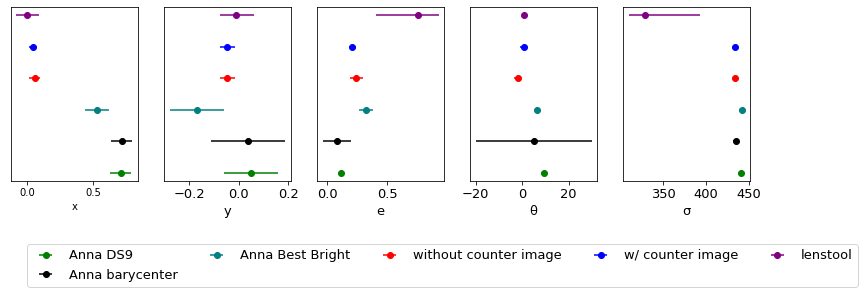

In [13]:
confidence_plot(1)

# CS82SL015824.81-003959.60

0.53


/home/joao/.local/lib/python3.8/site-packages/numpy/core/_asarray.py:102: UserWarning: Warning: converting a masked element to nan.
  return array(a, dtype, copy=False, order=order)


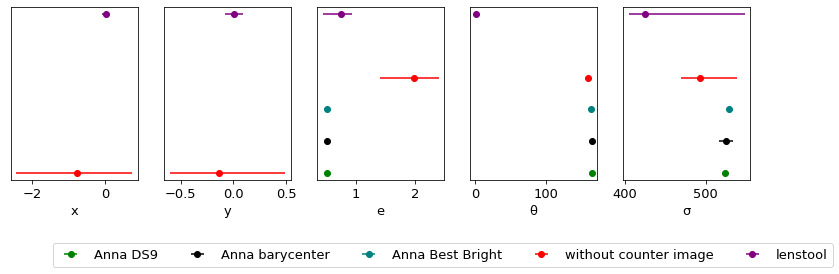

In [14]:
confidence_plot(2)

# CS82SL211527.25-003817.26

0.59


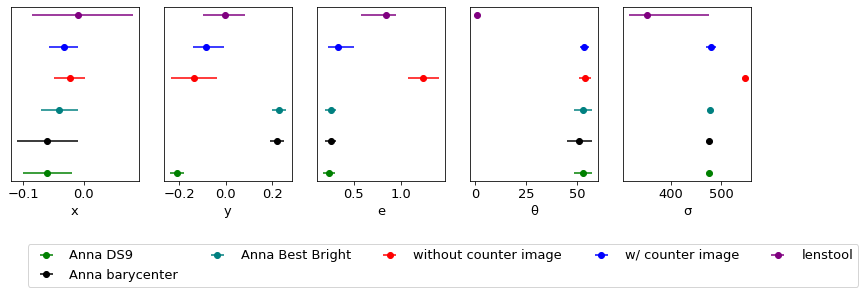

In [15]:
confidence_plot(3)

# CS82SL230521.68-000211.52

0.53


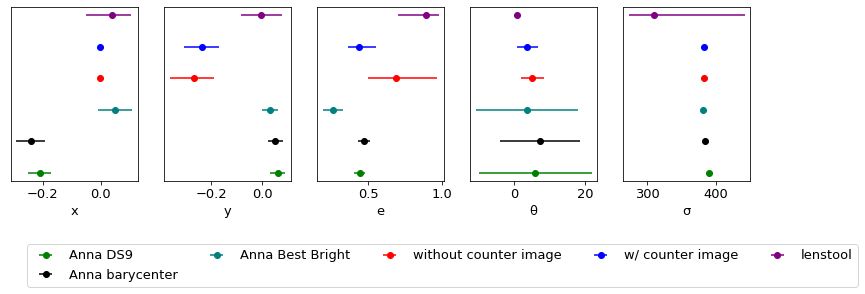

In [16]:
confidence_plot(4)